In [1]:
from sklearn.datasets import make_moons

In [12]:
x, y = make_moons(
    n_samples=300,
    noise=0.1,
    random_state=42
)

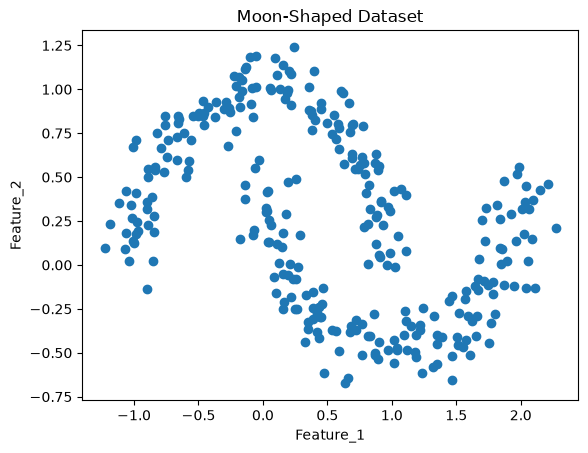

In [13]:
import matplotlib.pyplot as plt 

plt.scatter(x[:,0],x[:,1])
plt.xlabel('Feature_1')
plt.ylabel('Feature_2')
plt.title('Moon-Shaped Dataset')

plt.show()

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [15]:
from sklearn.cluster import DBSCAN

In [16]:
model = DBSCAN(
    eps=0.3,
    min_samples=5
)

In [17]:
labels = model.fit_predict(x_scaled)

In [18]:
labels[:20]

array([0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0])

In [19]:
import numpy as np

np.unique(labels, return_counts=True)

(array([-1,  0,  1]), array([  2, 149, 149]))

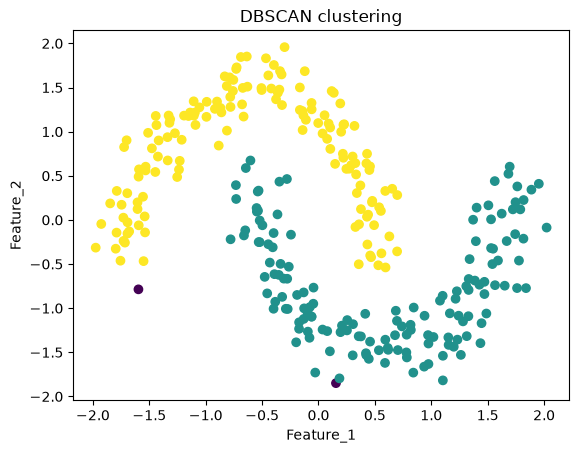

In [21]:
plt.scatter(
    x_scaled[:,0],
    x_scaled[:,1],
    c = labels
)

plt.xlabel('Feature_1')
plt.ylabel('Feature_2')
plt.title('DBSCAN clustering')

plt.show()

In [22]:
eps_values = [0.1, 0.2, 0.3, 0.4, 0.5]

for eps in eps_values:
    model = DBSCAN(
        eps=eps,
        min_samples=5
    )

    labels = model.fit_predict(x_scaled)

    unique_labels, counts = np.unique(labels, return_counts=True)

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = np.sum(labels == -1)

    print(
        f"eps={eps} | "
        f"Clusters={n_clusters} | "
        f"Noise={n_noise}"
    )

eps=0.1 | Clusters=11 | Noise=238
eps=0.2 | Clusters=7 | Noise=25
eps=0.3 | Clusters=2 | Noise=2
eps=0.4 | Clusters=1 | Noise=0
eps=0.5 | Clusters=1 | Noise=0


In [23]:
from sklearn.neighbors import NearestNeighbors

In [24]:
neighbors = NearestNeighbors(n_neighbors=5)

neighbors.fit(x_scaled)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
Name,Type,Value
effective_metric_ effective_metric_: strMetric used to compute distances to neighbors.,str,'eu...an'
effective_metric_params_ effective_metric_params_: dictParameters for the metric used to compute distances to neighbors.,dict,{}


In [25]:
distances, indices = neighbors.kneighbors(x_scaled)

In [26]:
k_distances = distances[:, -1]

In [27]:
k_distances = np.sort(k_distances)

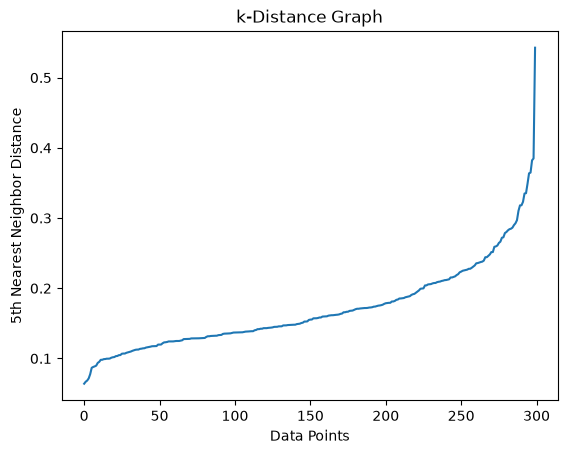

In [28]:
plt.plot(k_distances)

plt.xlabel("Data Points")
plt.ylabel("5th Nearest Neighbor Distance")
plt.title("k-Distance Graph")

plt.show()

Core Points   : 288
Border Points : 10
Noise Points  : 2


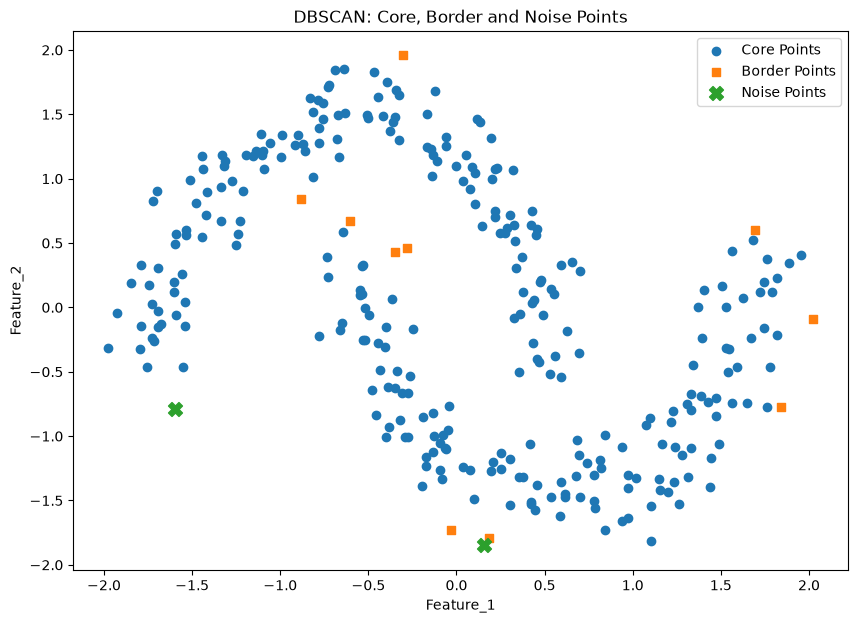

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

# DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=5)
labels = dbscan.fit_predict(x_scaled)

# Identify core points
core_indices = dbscan.core_sample_indices_

core_mask = np.zeros(len(x_scaled), dtype=bool)
core_mask[core_indices] = True

# Identify border points
border_mask = (~core_mask) & (labels != -1)

# Identify noise points
noise_mask = labels == -1

# Print counts
print("Core Points   :", core_mask.sum())
print("Border Points :", border_mask.sum())
print("Noise Points  :", noise_mask.sum())

# Visualization
plt.figure(figsize=(10, 7))

# Core points
plt.scatter(
    x_scaled[core_mask, 0],
    x_scaled[core_mask, 1],
    marker='o',
    label='Core Points'
)

# Border points
plt.scatter(
    x_scaled[border_mask, 0],
    x_scaled[border_mask, 1],
    marker='s',
    label='Border Points'
)

# Noise points
plt.scatter(
    x_scaled[noise_mask, 0],
    x_scaled[noise_mask, 1],
    marker='X',
    s=100,
    label='Noise Points'
)

plt.xlabel("Feature_1")
plt.ylabel("Feature_2")
plt.title("DBSCAN: Core, Border and Noise Points")
plt.legend()
plt.show()

In [34]:
from sklearn.cluster import DBSCAN
import numpy as np

for min_samples in [2, 3, 5, 10, 20]:

    dbscan = DBSCAN(
        eps=0.3,
        min_samples=min_samples
    )

    labels = dbscan.fit_predict(x_scaled)

    core_indices = dbscan.core_sample_indices_

    core_mask = np.zeros(len(x_scaled), dtype=bool)
    core_mask[core_indices] = True

    border_mask = (~core_mask) & (labels != -1)
    noise_mask = labels == -1

    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    print(
        f"min_samples={min_samples} | "
        f"Clusters={n_clusters} | "
        f"Core={core_mask.sum()} | "
        f"Border={border_mask.sum()} | "
        f"Noise={noise_mask.sum()}"
    )

min_samples=2 | Clusters=2 | Core=299 | Border=0 | Noise=1
min_samples=3 | Clusters=2 | Core=297 | Border=2 | Noise=1
min_samples=5 | Clusters=2 | Core=288 | Border=10 | Noise=2
min_samples=10 | Clusters=2 | Core=229 | Border=65 | Noise=6
min_samples=20 | Clusters=3 | Core=6 | Border=65 | Noise=229


# DBSCAN — Density-Based Spatial Clustering of Applications with Noise

## 1. What is DBSCAN?

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** is an unsupervised clustering algorithm that groups data points based on **density**.

Unlike K-Means:

* DBSCAN does **not require the number of clusters in advance**.
* DBSCAN can identify **noise/outliers**.
* DBSCAN can discover clusters with **irregular shapes**.
* DBSCAN is based on the density of neighboring points.

### Basic idea

```text
Dense region                    Sparse isolated point

● ● ● ● ●
● ● ● ● ●                    ●
 ● ● ● ●
● ● ● ● ●
```

Dense regions → clusters
Isolated points → noise

---

# 2. How DBSCAN Works

DBSCAN uses two important parameters:

```text
eps
│
└── Radius of neighborhood

min_samples
│
└── Minimum number of points required
    inside that neighborhood
```

Conceptually:

```text
                 DBSCAN
                    │
          ┌─────────┴─────────┐
          ↓                   ↓
        eps             min_samples
          ↓                   ↓
Neighborhood size      Density requirement
          └─────────┬─────────┘
                    ↓
          Core / Border / Noise
```

---

# 3. `eps`

`eps` defines the **maximum distance** within which another point is considered a neighbor.

```python
DBSCAN(eps=0.3)
```

means:

> Points within a distance of `0.3` are considered neighbors.

### Visualization

```text
             ●
        ●    ●    ●
             ●
             │
          eps radius
```

A larger `eps` means a larger neighborhood.

A smaller `eps` means a smaller neighborhood.

---

# 4. `min_samples`

`min_samples` determines how many points must exist within the `eps` neighborhood for a point to be considered a **core point**.

Example:

```python
DBSCAN(eps=0.3, min_samples=5)
```

The algorithm checks each point's `eps` neighborhood.

If the required number of points is present:

```text
→ Core point
```

---

# 5. Three Types of Points

DBSCAN classifies points into:

1. **Core points**
2. **Border points**
3. **Noise points**

```text
                 DBSCAN Point
                      │
             ┌────────┴────────┐
             ↓                 ↓
       Enough neighbors?       No
             │                 │
            Yes                ↓
             │          Near a core point?
             ↓             /        \
           CORE          Yes         No
                           ↓           ↓
                        BORDER       NOISE
```

---

# 6. Core Point

A **core point** has at least `min_samples` points in its `eps` neighborhood.

Example:

```text
       ● ● ●
     ●   ●   ●
       ● ● ●
          ↑
      Core point
```

With:

```python
eps = 0.3
min_samples = 5
```

if the point has at least the required number of points within its `eps` neighborhood:

```text
→ Core point
```

### Important

In scikit-learn, the point itself counts toward `min_samples`.

---

# 7. Border Point

A **border point** does not have enough neighbors to be a core point itself, but it lies within the `eps` neighborhood of a core point.

```text
       ● ● ● ●
     ● ● ● ● ●
       ● ● ●

             ■
             ↑
        Border point
```

The border point:

* Does not satisfy the density requirement itself.
* Is close enough to a core point.
* **Belongs to the cluster.**

### Important

**Border ≠ Noise**

A border point is still a member of a cluster.

---

# 8. Noise Point

A point is considered **noise** when:

1. It is not a core point.
2. It is not within `eps` of a core point.

```text
      ● ● ● ● ●
     ● ● ● ● ●
      ● ● ● ●


                         X
                         ↑
                       Noise
```

In scikit-learn, noise points receive the label:

```python
-1
```

---

# 9. Core vs Border vs Noise

| Type   | Enough neighbors? | Near a core point? | Cluster member? |
| ------ | ----------------: | -----------------: | --------------: |
| Core   |               Yes |                  — |             Yes |
| Border |                No |                Yes |             Yes |
| Noise  |                No |                 No |              No |

### Easy memory trick

> **Core = dense enough**
> **Border = not dense itself, but connected to a core**
> **Noise = neither**

---

# 10. DBSCAN Clusters

DBSCAN connects dense regions through core points.

```text
        Core points
       ● ● ● ● ●
      ● ● ● ● ●
       ● ● ● ●
             \
              ■
           Border
```

Core and border points together form the cluster.

```text
Cluster = Core + Border
```

Noise remains outside the clusters.

---

# 11. Why Border Points Were Included in Earlier Visualizations

When we used:

```python
labels = dbscan.fit_predict(x_scaled)
```

DBSCAN produced cluster labels such as:

```text
0 → Cluster 0
1 → Cluster 1
-1 → Noise
```

The cluster labels include **both core and border points**.

Therefore:

```text
Cluster
├── Core points
└── Border points
```

Only noise gets:

```python
-1
```

So a normal cluster visualization cannot automatically tell us whether a point is core or border.

To distinguish them, we used:

```python
core_mask
border_mask
noise_mask
```

and different markers.

---

# 12. DBSCAN Visualization

For our visualization:

```text
● → Core points
■ → Border points
✕ → Noise points
```

The **cluster color** and **point type** are different concepts.

For example:

```text
Cluster 0
├── ● Core
├── ● Core
├── ■ Border
└── ■ Border
```

All of them belong to the same cluster even though their point types are different.

---

# 13. `eps` Effect

### Very small `eps`

```text
eps ↓
```

Neighborhood becomes too small.

```text
●       ●       ●
```

Few points can find enough neighbors.

Result:

* More noise
* More small clusters
* Fewer core points

Our experiment:

```text
eps = 0.1 → Clusters = 11
             Noise = 238
```

---

### Reasonable `eps`

```text
eps = 0.3
```

Our dataset produced:

```text
Clusters = 2
Noise = 2
```

This was a good setting for our generated dataset.

---

### Very large `eps`

```text
eps ↑
```

Neighborhood becomes too large.

Separate clusters may become connected.

Our experiment:

```text
eps = 0.4 → Clusters = 1
             Noise = 0
```

So:

```text
eps too small → too much noise

eps appropriate → meaningful clusters

eps too large → clusters may merge
```

---

# 14. `min_samples` Effect

We kept:

```python
eps = 0.3
```

and changed `min_samples`.

Our results:

| `min_samples` | Clusters | Core | Border | Noise |
| ------------: | -------: | ---: | -----: | ----: |
|             2 |        2 |  299 |      0 |     1 |
|             3 |        2 |  297 |      2 |     1 |
|             5 |        2 |  288 |     10 |     2 |
|            10 |        2 |  229 |     65 |     6 |
|            20 |        3 |    6 |     65 |   229 |

### Observation

As:

```text
min_samples ↑
```

the density requirement becomes stricter.

Therefore:

```text
min_samples ↑
       ↓
Core points ↓
       ↓
Border / Noise can ↑
```

At:

```text
min_samples = 20
```

we obtained:

```text
Core = 6
Noise = 229
```

which was far too strict for our dataset.

---

# 15. `eps` and `min_samples` Together

The two parameters control different things:

```text
eps
 ↓
How far should I look?

min_samples
 ↓
How crowded should that area be?
```

### Example

```python
DBSCAN(
    eps=0.3,
    min_samples=5
)
```

means:

> Look within a radius of `0.3` and require the specified minimum number of points for a dense region.

---

# 16. Choosing `eps` — k-Distance Graph

A **k-distance graph** can help estimate a suitable `eps`.

The distances to the k-th nearest neighbors are:

1. Calculated for every point.
2. Sorted.
3. Plotted.

Example:

```text
Distance
   │
0.5│                         /
   │                       /
0.3│                  ____/
   │             ____/
0.2│___________/
   │
   └────────────────────────
             Data Points
```

Look for the **elbow / sharp change in slope**.

The corresponding distance can be used as an initial estimate for `eps`.

---

# 17. Our k-Distance Graph

Our graph showed a noticeable increase toward the right side.

This helped us investigate values around:

```text
eps ≈ 0.3
```

We then tested several values rather than blindly accepting one value.

This is important because the graph gives an **initial estimate**, not a guaranteed optimal value.

---

# 18. DBSCAN Parameter-Tuning Workflow

A practical workflow:

```text
1. Prepare data
       ↓
2. Handle missing values / preprocessing
       ↓
3. Scale features
       ↓
4. Choose initial min_samples
       ↓
5. Generate k-distance graph
       ↓
6. Estimate eps
       ↓
7. Run DBSCAN
       ↓
8. Check number of clusters
       ↓
9. Check noise points
       ↓
10. Evaluate clustering
       ↓
11. Visualize
       ↓
12. Adjust eps / min_samples
```

---

# 19. Why Scaling Is Important

DBSCAN is distance-based.

Suppose we have:

```text
age     → 20–60
income  → 20,000–200,000
```

Income has a much larger numerical scale.

Without scaling, it can dominate the distance calculation.

Therefore:

```python
x_scaled
```

is generally used before DBSCAN when features are on different scales.

---

# 20. Evaluating DBSCAN

Because DBSCAN is unsupervised, there are no normal target labels to compare against.

We can examine:

### Number of clusters

```text
Are we getting a sensible number of clusters?
```

### Noise

```text
Are we incorrectly classifying most points as noise?
```

### Visualization

```text
Do the clusters make sense?
```

### Silhouette Score

A silhouette score can be used to evaluate clustering quality when there are at least two clusters and the treatment of noise is handled appropriately.

Higher values generally indicate better separation.

For our dataset:

```text
Silhouette Score = 0.8182
```

---

# 21. Advantages of DBSCAN

### 1. No need to specify number of clusters

Unlike K-Means:

```python
KMeans(n_clusters=3)
```

DBSCAN does not require `k` beforehand.

### 2. Detects noise

```text
label = -1
```

can identify points that don't belong to any cluster.

### 3. Handles irregular cluster shapes

DBSCAN is not restricted to spherical clusters.

### 4. Useful for anomaly detection

Noise points can sometimes represent unusual observations.

### 5. Density-based

It forms clusters according to dense regions rather than distance from a centroid.

---

# 22. Limitations of DBSCAN

### 1. Sensitive to `eps`

Bad `eps` can produce:

```text
too much noise
```

or:

```text
clusters merging
```

### 2. Sensitive to `min_samples`

Too high:

```text
many points → noise
```

Too low:

```text
too many points → core
```

### 3. Struggles with varying-density clusters

A single `eps` may not work well when different clusters have very different densities.

```text
Dense cluster          Sparse cluster

●●●●●                  ●    ●
●●●●●                 ●  ●
●●●●●                    ●
```

### 4. Distance becomes difficult in high dimensions

In high-dimensional spaces, distance-based methods can become less effective.

---

# 23. DBSCAN vs K-Means

| Feature                            | K-Means            | DBSCAN               |
| ---------------------------------- | ------------------ | -------------------- |
| Type                               | Unsupervised       | Unsupervised         |
| Need number of clusters beforehand | Yes                | No                   |
| Based on                           | Centroids/distance | Density              |
| Detects noise                      | No                 | Yes                  |
| Irregular shapes                   | Limited            | Good                 |
| Main parameters                    | `k`                | `eps`, `min_samples` |
| Sensitive to scaling               | Yes                | Yes                  |
| Works with varying density         | Limited            | Limited              |
| Produces cluster labels            | Yes                | Yes                  |

---

# 24. DBSCAN Code — Basic Implementation

```python
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

labels = dbscan.fit_predict(x_scaled)
```

The resulting labels can look like:

```python
[0, 0, 1, 1, -1, 0, 1, ...]
```

where:

```text
0 → Cluster 0
1 → Cluster 1
-1 → Noise
```

---

# 25. Core, Border and Noise Visualization

```python
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=0.3,
    min_samples=5
)

labels = dbscan.fit_predict(x_scaled)

# Core points
core_indices = dbscan.core_sample_indices_

core_mask = np.zeros(len(x_scaled), dtype=bool)
core_mask[core_indices] = True

# Border points
border_mask = (~core_mask) & (labels != -1)

# Noise points
noise_mask = labels == -1

print("Core Points   :", core_mask.sum())
print("Border Points :", border_mask.sum())
print("Noise Points  :", noise_mask.sum())

plt.figure(figsize=(10, 7))

plt.scatter(
    x_scaled[core_mask, 0],
    x_scaled[core_mask, 1],
    marker='o',
    label='Core Points'
)

plt.scatter(
    x_scaled[border_mask, 0],
    x_scaled[border_mask, 1],
    marker='s',
    label='Border Points'
)

plt.scatter(
    x_scaled[noise_mask, 0],
    x_scaled[noise_mask, 1],
    marker='X',
    s=100,
    label='Noise Points'
)

plt.xlabel("Feature_1")
plt.ylabel("Feature_2")
plt.title("DBSCAN: Core, Border and Noise Points")
plt.legend()
plt.show()
```

---

# 26. Complete Mental Model 🧠

```text
                         DBSCAN
                            │
               ┌────────────┴────────────┐
               ↓                         ↓
              eps                  min_samples
               ↓                         ↓
       Neighborhood radius        Density requirement
               │                         │
               └────────────┬────────────┘
                            ↓
                    Examine each point
                            │
                 ┌──────────┴──────────┐
                 ↓                     ↓
          Enough neighbors?            No
                 │                     │
                Yes                    ↓
                 │              Near a core point?
                 ↓                 /          \
               CORE              Yes           No
                                   ↓             ↓
                                BORDER         NOISE
                                   │             │
                                   ↓             ↓
                              Cluster member     -1
```

## ⭐ Key points to remember

> **DBSCAN = density-based clustering + noise detection**

> **`eps` = neighborhood radius**

> **`min_samples` = minimum density requirement**

> **Core = enough neighbors**

> **Border = not enough neighbors itself, but reachable from a core**

> **Noise = neither core nor connected to a core**

> **Core + Border = cluster**

> **Noise = `-1`**

> **k-distance graph helps estimate `eps`**

> **Scaling is important because DBSCAN relies on distance**

> **`eps` and `min_samples` should be tuned together**

> **DBSCAN does not require the number of clusters beforehand**
